## 0. Load Libraries


In [4]:
import nltk
from nltk.corpus import brown

nltk.download("brown")


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\sia\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

# D0. Load and preprocess in one pipeline

In [5]:
# Load sentences
sents = brown.sents(categories="news")


# Preprocess
import re

def is_punct(token):
    return re.fullmatch(r"\W+", token) is not None

def preprocess_sents(tokens):
    out = []
    for t in tokens:
        t = t.lower().strip()
        if not t:
            continue
        if is_punct(t):
            continue
        out.append(t)
    out = ["<bos>"] + out + ["<eos>"]
    return out

preprocessed_sents = [preprocess_sents(s) for s in sents]

print(preprocessed_sents[0])
print ("length of first sentence:", len(preprocessed_sents[0]))


['<bos>', 'the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', '<eos>']
length of first sentence: 24


# D1. Split (used for both models)

In [6]:
import random

random.seed(42)  # I want to make sure the results are reproducible
random.shuffle(preprocessed_sents)

n = len(preprocessed_sents)
n_train = int(n * 0.8)
n_val = int(n * 0.1)

train_sents = preprocessed_sents[:n_train]
val_sents = preprocessed_sents[n_train:n_train+n_val]
test_sents = preprocessed_sents[n_train+n_val:] 


# Sentences Analysis

print ("\n","=" * 50, "\n")
print (" " * 15 , "Sentences Analysis")
print ("\n","=" * 50, "\n")
print("number of sentences in original set:", len(preprocessed_sents))
print("number of sentences in train set:", len(train_sents)," _ Porportion:", round((len(train_sents)/len(preprocessed_sents)) * 100,2),"%")
print("number of sentences in validation set:", len(val_sents)," _ Porportion:", round((len(val_sents)/len(preprocessed_sents)) * 100,2),"%")
print("number of sentences in test set:", len(test_sents)," _ Porportion:", round((len(test_sents)/len(preprocessed_sents)) * 100,2),"%")


# Tokens Analysis

print ("\n","=" * 50, "\n")
print (" " * 15 , "Token Analysis")
print ("\n","=" * 50, "\n")

train_tokens = sum(len(sent) for sent in train_sents)
val_tokens = sum(len(sent) for sent in val_sents)
test_tokens = sum(len(sent) for sent in test_sents)
all_tokens = train_tokens + val_tokens + test_tokens

print("number of all tokens in original set:", all_tokens)
print("number of tokens in train set:", train_tokens," _ Porportion:", round((train_tokens/all_tokens)*100,2),"%")
print("number of tokens in validation set:", val_tokens," _ Porportion:", round((val_tokens/all_tokens)*100,2),"%")
print("number of tokens in test set:", test_tokens," _ Porportion:", round((test_tokens/all_tokens)*100,2),"%")








                Sentences Analysis


number of sentences in original set: 4623
number of sentences in train set: 3698  _ Porportion: 79.99 %
number of sentences in validation set: 462  _ Porportion: 9.99 %
number of sentences in test set: 463  _ Porportion: 10.02 %


                Token Analysis


number of all tokens in original set: 97838
number of tokens in train set: 78509  _ Porportion: 80.24 %
number of tokens in validation set: 9556  _ Porportion: 9.77 %
number of tokens in test set: 9773  _ Porportion: 9.99 %


# D2. Vocabulary (Shared)

In [7]:
from collections import Counter

min_freq = 2

counter = Counter()
for sent in train_sents:
    counter.update(sent)

vocab = ["<unk>"] + [word for word, freq in counter.items() if freq >= min_freq and word != "<unk>"]



print ("min freq:", min_freq)
print("Vocabulary size(only in train set):", len(vocab))

print ("\n","=" * 50, "\n")
print ("top 20 most frequent words in train set:","\n")
print(" word    frequency")
for word, freq in counter.most_common(20):
    print(f"{word}: {freq}")


min freq: 2
Vocabulary size(only in train set): 5435


top 20 most frequent words in train set: 

 word    frequency
the: 5116
<bos>: 3698
<eos>: 3698
of: 2287
and: 1768
a: 1720
to: 1716
in: 1623
for: 786
that: 658
is: 582
was: 574
on: 535
he: 514
at: 513
with: 459
as: 427
be: 422
by: 409
it: 376


# Part A - Statistical trigram language model

## A1. Train a Trigram Language Model

In [8]:

from nltk.lm import MLE, Laplace, Lidstone
from nltk.util import everygrams
from nltk.lm import Vocabulary

n = 3 # Trigram


def map_to_vocab(sent, vocab_set, unk_token="<unk>"):
    return [word if word in vocab_set else unk_token for word in sent]

vocab_set = set(vocab)

train_sents_mapped = [map_to_vocab(sent, vocab_set) for sent in train_sents]
val_sents_mapped = [map_to_vocab(sent, vocab_set) for sent in val_sents]
test_sents_mapped = [map_to_vocab(sent, vocab_set) for sent in test_sents]


# Building the language model

def only_trigrams(sent): # max_len = n ==> returns 1-grams, 2-grams, 3-grams, but we only want 3-grams
    return [g for g in everygrams(sent, max_len=n) if len(g) == n]


train_trigrams = [only_trigrams(sent) for sent in train_sents_mapped]
val_trigrams   = [only_trigrams(sent) for sent in val_sents_mapped]
test_trigrams  = [only_trigrams(sent) for sent in test_sents_mapped]


alpha = 0.1 # smoothing strength
lm_vocab = Vocabulary(vocab)
lm = Lidstone(alpha,n)


lm.fit(train_trigrams, lm_vocab)

print("Trigram model trained.")
print("Model vocab size:", len(lm_vocab))



Trigram model trained.
Model vocab size: 5436


Note: Why did I choose `Lidstone`?

 MLE doesn't eliminate zero probabilities, if there is one zero probability, the whole sentence will have zero probability, which is simple for training but not good for evaluation and real world scenarios.

 Laplace(Add-one smoothing) adds 1 to each n-gram, this will eliminate zero probability, but it's too aggressive and gives too much weight to not seen n-grams, as a result it will have poor performance on bigger vocabularies.

 Lidstone: the idea is similar to Laplace but instead of adding 1, it adds alpha value which is a small value, it's softer than Laplace, and keeps a balance between seen and unseen n-grams. That's why I chose Lidstone.


## A2. Evaluate with Perplexity


In [9]:
# flatten validation trigrams
val_trigrams_flat = [g for sent in val_trigrams for g in sent]
test_trigrams_flat = [g for sent in test_trigrams for g in sent]


val_pp = lm.perplexity(val_trigrams_flat)
test_pp = lm.perplexity(test_trigrams_flat)

print("Validation Perplexity:", val_pp)
print("Test Perplexity:", test_pp)

Validation Perplexity: 2535.6302358362896
Test Perplexity: 2495.5938420059892


Interpretation:

Is it high or low relative to your expectations?

Yes, it's very high. Perplexity means, on average model is hesitating between 2535 options (in validation set) while predicting next word. It's like it has around 2535 equally likely choices. I guess there are several reasons for that. 

1. Brown corpus is very big and versatile. Since it's in news category, the news category is usually complex. 
2. Trigram has a very short memory. it only sees the 2 previous words, but the natural Language has longer dependencies.
3. we chose min_freq = 2, which caused some rare words to be mapped `<unk>` which reduces information.

What factors affect perplexity?

1. Smoothing method and strength, if we have chosen MLE, the result would have been much higher. Even Laplcace could result in higher perplexity compared to Lidstone.
2. Maybe increasing the memory. Increasing [n] may improve performance if enough data is available, but it can also increase sparsity and overfitting.
3. min-freq, if we set this parameter to lower values, we may have less `<unk>` and rare words are seen better, but the vocabulary size will grow and the model will fit better on training data and maybe the perplexity would decrease, but doing so will definitly increase the risk of overfitting.


## A3. Text Generation


In [10]:


def generate_text_trigram_safe(model, train_sents_mapped, min_length=30, max_length=60, max_attempts=2000):
    seed_sent = random.choice(train_sents_mapped)
    text = list(seed_sent[:2])

    attempts = 0
    while len(text) < min_length and len(text) < max_length and attempts < max_attempts:
        attempts += 1
        context = tuple(text[-2:])

        try:
            nxt = model.generate(1, text_seed=context)
        except ValueError:
            seed_sent = random.choice(train_sents_mapped)
            text += list(seed_sent[:2])
            continue

        next_word = nxt[0] if isinstance(nxt, list) else nxt

        if next_word == "<eos>":
            if len(text) < min_length:
                seed_sent = random.choice(train_sents_mapped)
                text += list(seed_sent[:2])
                continue
            else:
                break

        text.append(next_word)

    return " ".join(text[2:])

random.seed(42)

for i in range(3):
    print(f"\nSample {i+1}:")
    print(generate_text_trigram_safe(lm, train_sents_mapped, min_length=30))
    print("=" * 60)


Sample 1:
has <unk> up harry truman and in september retail sales were <unk> stars in football basketball and baseball mantle in commerce okla. maris in 1961 with the <unk>

Sample 2:
<unk> grant is spending several weeks in florida <bos> a <unk> from <unk> had time to turn to <unk> <unk> told police he followed as the more successful

Sample 3:
was charged with four counts of assault on an officer <unk> arrest <unk> and <unk> the <unk> was knocked down the hill and we must stay together the


**Are they grammatical?**

The generated sentences are partially grammatical at the local level. Many short phrases such are syntactically correct. But, the sentences are not fully well-formed and often contain incomplete clauses, repeated structures.

**Are they coherent?**

No, the generated texts are not fully coherent. Although short fragments seem reasonable, the overall meaning shifts abruptly. The model fails to maintain a consistent topic and long-term semantic structure.

**What limitations do you observe?**

The trigram model has very limited memory (only two previous words). It cannot capture long-range dependencies in natural language.

Topic drift occurs frequently.

The <unk> token reduces semantic quality.

Sentences may end abruptly or lack logical closure.

# Part B - Neural Language Model with RNN

In [11]:
# ===== 1) Setup =====
import re
import math
import random
from collections import Counter
from dataclasses import dataclass
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader



# Reproducibility (optional)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [12]:
# ===== 2) Configuration (edit if needed) =====
# You can edit these hyperparameters as needed. The defaults should work for a basic run.
# This are not fixed rules, just a starting point. Feel free to experiment with different values!
# This parameter class is just a convenient way to store all the settings in one place. You can also use a dictionary or command-line arguments if you prefer.
# These parameters define the dataset category, how to split the data, vocabulary cutoff, model architecture, and training settings. Adjusting these can affect the performance and training time of your model.
@dataclass
class Config:
    category: str = "news"
    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10

    min_freq: int = 2       # vocab cutoff (train only)
    seq_len: int = 30       # T
    batch_size: int = 32

    emb_dim: int = 128
    hid_dim: int = 256
    num_layers: int = 1
    dropout: float = 0.0    # use 0.0 if num_layers == 1

    lr: float = 1e-3
    epochs: int = 5
    grad_clip: float = 1.0  # optional but recommended

cfg = Config()

SPECIAL = {"BOS": "<bos>", "EOS": "<eos>", "UNK": "<unk>"}

## B1. Numericalization and Training Example Creation

#### B1-Step 1: Numericalization

In [13]:

# 1) Build token<->id mappings from the existing shared vocabulary

itos = list(vocab)  # id -> token (stable order based on vocab)
stoi = {tok: idx for idx, tok in enumerate(itos)}  # token -> id

UNK_TOKEN = "<unk>"
unk_id = stoi[UNK_TOKEN]

def numericalize_sentence(tokens, stoi, unk_id):
    """
    Convert a tokenized sentence (list of strings) into a list of integer IDs.
    Any token not found in `stoi` is mapped to <unk>.
    """
    return [stoi.get(tok, unk_id) for tok in tokens]



example_sent = train_sents_mapped[0]   
example_ids = numericalize_sentence(example_sent, stoi, unk_id)

print("Example sentence (tokens):")
print(example_sent)

print("\nNumericalized (IDs):")
print(example_ids)

print("\nCheck a few token->id pairs:")
for tok in example_sent[:10]:
    print(f"{tok:>12} -> {stoi.get(tok, unk_id)}")

Example sentence (tokens):
['<bos>', 'breeding', 'to', 'adair', 'to', 'gentile', 'setting', 'up', '<unk>', '<unk>', 'homer', 'over', 'the', 'wall', 'in', 'left', 'center', '<eos>']

Numericalized (IDs):
[1, 2, 3, 4, 3, 5, 6, 7, 0, 0, 8, 9, 10, 11, 12, 13, 14, 15]

Check a few token->id pairs:
       <bos> -> 1
    breeding -> 2
          to -> 3
       adair -> 4
          to -> 3
     gentile -> 5
     setting -> 6
          up -> 7
       <unk> -> 0
       <unk> -> 0


#### B1-Step 2: Build Token Streams


In [15]:


def build_stream(sents_mapped, stoi, unk_id):
    """
    Convert list of tokenized sentences -> one long list of token IDs (token stream).
    """
    stream = []
    for sent in sents_mapped:
        stream.extend(numericalize_sentence(sent, stoi, unk_id))
    return stream

train_stream = build_stream(train_sents_mapped, stoi, unk_id)
val_stream   = build_stream(val_sents_mapped, stoi, unk_id)
test_stream  = build_stream(test_sents_mapped, stoi, unk_id)

print("Token stream sizes (number of IDs):")
print(f"Length of train_stream: {len(train_stream)}")
print(f"Length of val_stream:   {len(val_stream)}")
print(f"Length of test_stream:  {len(test_stream)}")

# Quick sanity check: show first 30 IDs and their tokens for train_stream
print("\nFirst 30 tokens from train_stream:")
first_ids = train_stream[:30]
print(first_ids)
print([itos[i] if 0 <= i < len(itos) else "<bad_id>" for i in first_ids])

# Check how many <unk> appear in each stream
print("\n<unk> counts:")
print(f"train: {sum(1 for i in train_stream if i == unk_id)}")
print(f"val:   {sum(1 for i in val_stream if i == unk_id)}")
print(f"test:  {sum(1 for i in test_stream if i == unk_id)}")

Token stream sizes (number of IDs):
Length of train_stream: 78509
Length of val_stream:   9556
Length of test_stream:  9773

First 30 tokens from train_stream:
[1, 2, 3, 4, 3, 5, 6, 7, 0, 0, 8, 9, 10, 11, 12, 13, 14, 15, 1, 10, 16, 17, 18, 19, 10, 20, 21, 22, 23, 0]
['<bos>', 'breeding', 'to', 'adair', 'to', 'gentile', 'setting', 'up', '<unk>', '<unk>', 'homer', 'over', 'the', 'wall', 'in', 'left', 'center', '<eos>', '<bos>', 'the', 'court', 'first', 'ruled', 'that', 'the', 'strike', 'constituted', 'only', 'an', '<unk>']

<unk> counts:
train: 6246
val:   1196
test:  1205


#### B1-Step 3: Create Input/Target Pairs


In [17]:


class LanguageModelDataset(Dataset):
    def __init__(self, token_stream, seq_len):
        self.data = torch.tensor(token_stream, dtype=torch.long)
        self.seq_len = seq_len

        self.max_start = len(self.data) - (self.seq_len + 1)

    def __len__(self):
        return self.max_start + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

# ===== Build datasets
train_ds = LanguageModelDataset(train_stream, cfg.seq_len)
val_ds   = LanguageModelDataset(val_stream, cfg.seq_len)
test_ds  = LanguageModelDataset(test_stream, cfg.seq_len)

print("Dataset sizes (#samples):")
print(f"train_ds: {len(train_ds)}")
print(f"val_ds:   {len(val_ds)}")
print(f"test_ds:  {len(test_ds)}")

# Sanity check: inspect one sample
x0, y0 = train_ds[0]
print("\nOne sample shapes:")
print("x0 shape:", x0.shape)
print("y0 shape:", y0.shape)

print("\nFirst sample (tokens):")
print("x0 tokens:", [itos[i.item()] for i in x0[:15]])
print("y0 tokens:", [itos[i.item()] for i in y0[:15]])

# Check the shift property on first few positions
print("\nShift check (first 8 positions):")
for i in range(8):
    print(f"x[{i}]={itos[x0[i].item()]:>10}  -> y[{i}]={itos[y0[i].item()]:>10}")


# ===== DataLoaders + sanity check 
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, drop_last=True)

x_batch, y_batch = next(iter(train_loader))
print ("\n","=" * 50, "\n")
print("\nExpected shape:", (cfg.batch_size,cfg.seq_len))

print("x_batch shape:", x_batch.shape)  # expected: (B, T)
print("y_batch shape:", y_batch.shape)  # expected: (B, T)
print("x_batch dtype:", x_batch.dtype)


print("First 10 x:", x_batch[0][:10].tolist())
print("First 10 y:", y_batch[0][:10].tolist())

Dataset sizes (#samples):
train_ds: 78479
val_ds:   9526
test_ds:  9743

One sample shapes:
x0 shape: torch.Size([30])
y0 shape: torch.Size([30])

First sample (tokens):
x0 tokens: ['<bos>', 'breeding', 'to', 'adair', 'to', 'gentile', 'setting', 'up', '<unk>', '<unk>', 'homer', 'over', 'the', 'wall', 'in']
y0 tokens: ['breeding', 'to', 'adair', 'to', 'gentile', 'setting', 'up', '<unk>', '<unk>', 'homer', 'over', 'the', 'wall', 'in', 'left']

Shift check (first 8 positions):
x[0]=     <bos>  -> y[0]=  breeding
x[1]=  breeding  -> y[1]=        to
x[2]=        to  -> y[2]=     adair
x[3]=     adair  -> y[3]=        to
x[4]=        to  -> y[4]=   gentile
x[5]=   gentile  -> y[5]=   setting
x[6]=   setting  -> y[6]=        up
x[7]=        up  -> y[7]=     <unk>



Expected shape: (32, 30)
x_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 30])
x_batch dtype: torch.int64
First 10 x: [647, 1381, 5040, 3, 10, 2707, 91, 124, 2463, 10]
First 10 y: [1381, 5040, 3, 10, 2707, 91, 12

# B2 - Build the RNN Language Model

In [ ]:

VOCAB_SIZE = len(itos)

class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        """
        x: (batch_size, seq_len) token IDs
        returns:
          logits: (batch_size, seq_len, vocab_size)
          h_n: (num_layers, batch_size, hidden_dim)
        """
        emb = self.embedding(x)          # (B, T, E)
        out, h_n = self.rnn(emb, h0)     # out: (B, T, H)
        logits = self.fc(out)            # (B, T, V)
        return logits, h_n

model = RNNLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim= cfg.emb_dim,
    hidden_dim=cfg.hid_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout
).to(device)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print("Model parameters:", num_params)

Model parameters: 2191291


In [28]:
print("Total Number of model Parameters:", num_params  )
print("Embedding dimension:", cfg.emb_dim)
print("Hidden dimension:", cfg.hid_dim)
print("Number of RNN layers:", cfg.num_layers)
print("Learning rate:", cfg.lr)
print("sequence length:", cfg.seq_len)


Total Number of model Parameters: 2191291
Embedding dimension: 128
Hidden dimension: 256
Number of RNN layers: 1
Learning rate: 0.001
sequence length: 30


# 8) B3 – Training + validation (loss + perplexity)

In [22]:
#-----------------------------------------------
# Loss function 
#-----------------------------------------------
criterion = nn.CrossEntropyLoss()

#-----------------------------------------------
# Optimizer
#-----------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)


In [23]:

#-----------------------------------------------
# Helper to compute perplexity
#-----------------------------------------------
@torch.no_grad()
def evaluate_perplexity(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # 1) logits = model(x) -> (B, T, V)
        logits, _ = model(x)

        # 2) reshape logits to (B*T, V)
        B, T, V = logits.shape
        logits_flat = logits.reshape(B * T, V)

        # 3) reshape y to (B*T,)
        y_flat = y.reshape(B * T)

        # 4) loss = criterion(...)
        loss = criterion(logits_flat, y_flat)

        # 5) accumulate total_loss weighted by number of tokens
        num_tokens = B * T
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    ppl = math.exp(avg_loss)
    return ppl



In [ ]:
#-----------------------------------------------
# Train one epoch
#-----------------------------------------------

import torch.nn.utils as nn_utils

def train_one_epoch(model: nn.Module, loader: DataLoader) -> float:
    model.train()
    running_loss = 0.0
    running_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # 1) zero grads
        optimizer.zero_grad()

        # 2) forward
        logits, _ = model(x)  # (B, T, V)

        # 3) reshape for CE
        B, T, V = logits.shape
        logits_flat = logits.reshape(B * T, V)
        y_flat = y.reshape(B * T)

        # 4) loss
        loss = criterion(logits_flat, y_flat)

        # 5) backward
        loss.backward()

        # 6) optional: clip gradients
        if cfg.grad_clip is not None:
            nn_utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        # 7) step
        optimizer.step()

        # 8) accumulate weighted by tokens
        num_tokens = B * T
        running_loss += loss.item() * num_tokens
        running_tokens += num_tokens

    return running_loss / max(running_tokens, 1)


In [ ]:
#-----------------------------------------------
# Training loop
#-----------------------------------------------
train_losses = []
val_ppls = []

for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_ppl = evaluate_perplexity(model, val_loader)

    train_losses.append(train_loss)
    val_ppls.append(val_ppl)

    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | val ppl: {val_ppl:.2f}")





Epoch 01 | train loss: 1.9020 | val ppl: 885.51
Epoch 02 | train loss: 0.8734 | val ppl: 2604.91
Epoch 03 | train loss: 0.5756 | val ppl: 5392.54
Epoch 04 | train loss: 0.4638 | val ppl: 8965.05
Epoch 05 | train loss: 0.4089 | val ppl: 13116.96


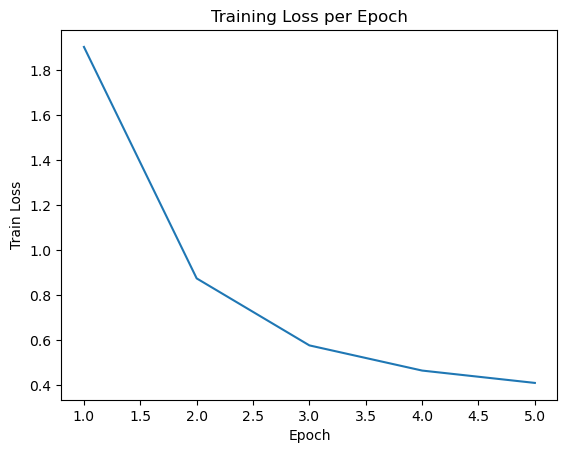

In [27]:
#-----------------------------------------------
# Plot training loss
#-----------------------------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss per Epoch")
plt.show()

#  B4 - Test Perplexity and Text Generation

In [29]:
#-----------------------------------------------
# Test perplexity
#-----------------------------------------------
test_ppl = evaluate_perplexity(model, test_loader)  # will work after TODOs done
print("Test perplexity:", test_ppl)


Test perplexity: 13527.504986756088


In [ ]:
#-----------------------------------------------
# Text Generation
#-----------------------------------------------

from typing import Dict, List


def sample_next_token(logits_1v: torch.Tensor, temperature: float = 1.0) -> int:
    if temperature <= 0:
        raise ValueError("temperature must be > 0")
    scaled = logits_1v / temperature
    probs = torch.softmax(scaled, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

@torch.no_grad()
def generate_text(model: nn.Module, stoi: Dict[str, int], itos: List[str],
                  max_new_tokens: int = 80,
                  min_tokens: int = 30,
                  temperature: float = 1.0,
                  seed: int = 42) -> str:
    model.eval()

    # reproducibility (optional)
    if seed is not None:
        torch.manual_seed(seed)

    bos_id = stoi["<bos>"]
    eos_id = stoi["<eos>"]

    generated = [bos_id]

    while len(generated) - 1 < max_new_tokens:
        x = torch.tensor([generated], dtype=torch.long, device=device)
        logits, _ = model(x)
        last_logits = logits[0, -1, :]

        next_id = sample_next_token(last_logits, temperature=temperature)

        # enforce minimum length: ignore early eos
        if next_id == eos_id and (len(generated) - 1) < min_tokens:
            continue

        generated.append(next_id)

        if next_id == eos_id:
            break

    tokens = [itos[i] for i in generated]

    # Optional: remove <bos> and <eos> from display if you want
    # tokens = [t for t in tokens if t not in ["<bos>", "<eos>"]]

    return " ".join(tokens)


temps = [1.2, 1.0, 0.7]      
seeds = [10, 20, 30]         

for i in range(3):
    text = generate_text(
        model, stoi, itos,
        max_new_tokens=80,
        min_tokens=30,
        temperature=temps[i],
        seed=seeds[i]
    )
    print(f"\nSample {i+1} (temp={temps[i]}, seed={seeds[i]}):")
    print(text)








Sample 1 (temp=1.2, seed=10):
<bos> it today more than the <unk> sum of <unk> house is must <unk> being still like his man and over the program and his bride was given in marriage by her father <eos>

Sample 2 (temp=1.0, seed=20):
<bos> within view of the avenue are some of the united states government's tremendous buildings plus <unk> and <unk> <unk> shortstop of the game of the 1960 season he pointed out the <unk> <unk> still more confidence to provide federal grants to states for specified efforts in <unk> this <unk> crime trend <eos>

Sample 3 (temp=0.7, seed=30):
<bos> the <unk> <unk> ten tires and <unk> one of the <unk> <unk> <unk> and <unk> earl eaton of north dallas which is located above the social security payroll tax by a stroke <eos>


## B4 – Text Generation Analysis

### Sample 1

**Grammaticality:**  
The sentence is partially grammatical. The ending part, such as *"his bride was given in marriage by her father"*, is grammatically correct and well-formed. However, the beginning of the sentence contains incorrect structures like *"house is must being"*, which is not grammatically valid.

**Coherence:**  
The sentence lacks overall coherence. Different fragments appear to be combined without a clear logical connection. For example, there is no meaningful relation between "sum of house" and "bride was given in marriage".

**Repetition:**  
There is no strong word repetition, but the repeated use of "and" shows weak sentence structuring.

**Long-range dependency behavior:**  
The model successfully generated a correct passive structure at the end of the sentence. This shows that the RNN learned some short-range syntactic dependencies, but it struggles to maintain structure over longer spans.

---

### Sample 2

**Grammaticality:**  
This sample is the most grammatical among the three. The beginning of the sentence strongly resembles real news text, such as *"within view of the avenue are some of the united states government's tremendous buildings"*. However, the sentence shifts topic abruptly later on.

**Coherence:**  
Coherence is moderate. The sentence starts with government buildings, then suddenly moves to a baseball season, and later to federal grants and crime trends. The topic is not consistently maintained.

**Repetition:**  
There is no excessive direct repetition, but the formal news-style structure appears repeatedly.

**Long-range dependency behavior:**  
The model is able to generate relatively long sentences without completely breaking down. This indicates that it learned short- to medium-range dependencies, but it still struggles with maintaining a consistent topic over longer contexts.

---

### Sample 3

**Grammaticality:**  
This sample is less grammatical compared to Sample 2. Some parts, such as *"which is located above the social security payroll tax"*, are structurally correct. However, the frequent use of `<unk>` tokens makes the sentence unnatural.

**Coherence:**  
Coherence is low. The sentence does not follow a clear topic and combines unrelated fragments.

**Repetition:**  
There is no strong repetition of specific words, but the large number of `<unk>` tokens reduces fluency and clarity.

**Long-range dependency behavior:**  
The model correctly generated a relative clause (*"which is located..."*), showing that it learned certain syntactic patterns. However, it still has difficulty maintaining meaningful long-range semantic structure.

---

### Overall Observation

Compared to the trigram model from Section A, the RNN model generates longer and more structurally complex sentences. It demonstrates better grammatical patterns and can produce structures such as passive voice and relative clauses. However, it still struggles with global coherence and maintaining a consistent topic throughout the sentence. Additionally, the presence of `<unk>` tokens reduces the naturalness of the generated text.